<a href="https://colab.research.google.com/github/aabyyaann/UAS-ML/blob/main/Transaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q tensorflow optuna mlflow lime seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.5 MB/s eta 0:00:00
   

In [3]:
import os
import gc
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.feature_selection import (
    VarianceThreshold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.utils.class_weight import (
    compute_class_weight
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

import optuna

import mlflow
import mlflow.tensorflow

from lime.lime_tabular import LimeTabularExplainer

In [4]:
os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [5]:
DATA_PATH = "/content/drive/MyDrive/Midterm ML/train_transaction.csv"

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print(df.shape)

df.head()

(590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


isFraud
0    569877
1     20663
Name: count, dtype: int64


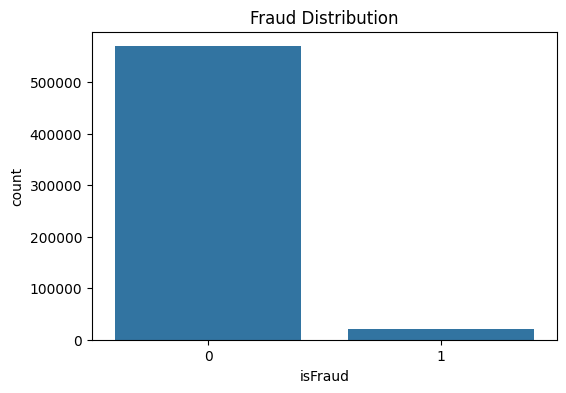

In [7]:
fraud_dist = df["isFraud"].value_counts()

print(fraud_dist)

plt.figure(figsize=(6,4))

sns.countplot(
    x=df["isFraud"]
)

plt.title("Fraud Distribution")

plt.show()

In [8]:
fraud_pct = (
    df["isFraud"]
    .value_counts(normalize=True)
    *100
)

fraud_pct

,proportion
isFraud,
0,96.500999
1,3.499001


In [9]:
missing = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      *100
)

missing.head(20)

,0
dist2,93.628374
D7,93.409930
D13,89.509263
D14,89.469469
D12,89.041047
D6,87.606767
D9,87.312290
D8,87.312290
V153,86.123717
V149,86.123717


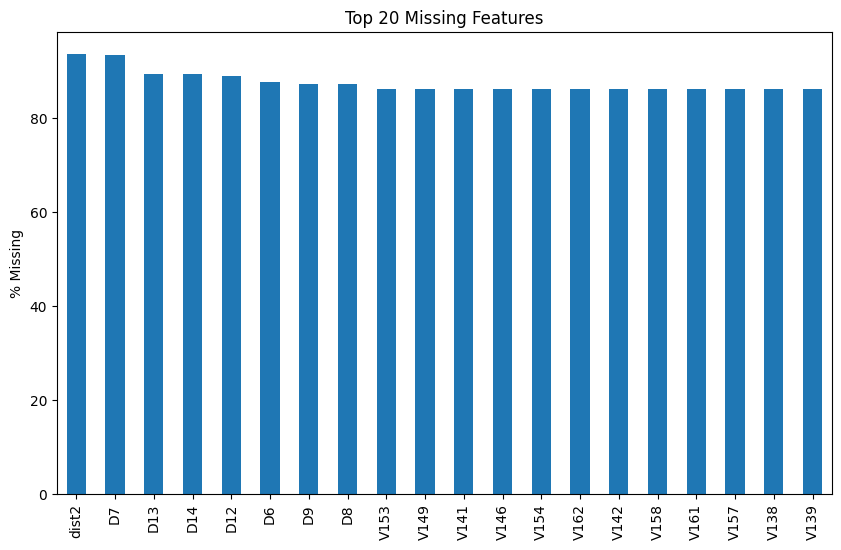

In [10]:
top_missing = missing.head(20)

plt.figure(figsize=(10,6))

top_missing.plot(kind="bar")

plt.title(
    "Top 20 Missing Features"
)

plt.ylabel("% Missing")

plt.show()

In [11]:
threshold = 90

drop_cols = missing[
    missing > threshold
].index

print(
    "Dropped Columns:",
    len(drop_cols)
)

df.drop(
    columns=drop_cols,
    inplace=True
)

print(
    df.shape
)

Dropped Columns: 2
(590540, 392)


In [12]:
X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

In [13]:
if "TransactionID" in X.columns:

    X.drop(
        columns=["TransactionID"],
        inplace=True
    )

print(X.shape)

(590540, 390)


In [14]:
numeric_cols = X.select_dtypes(
    include=[
        "int64",
        "float64"
    ]
).columns

categorical_cols = X.select_dtypes(
    include=[
        "object"
    ]
).columns

print(
    "Numeric:",
    len(numeric_cols)
)

print(
    "Categorical:",
    len(categorical_cols)
)

Numeric: 376
Categorical: 14


In [15]:
for col in numeric_cols:

    X[col] = X[col].fillna(
        X[col].median()
    )

for col in categorical_cols:

    X[col] = X[col].fillna(
        "Unknown"
    )

print(
    X.isnull().sum().sum()
)

0


In [16]:
encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    encoders[col] = le

print(
    "Encoding selesai"
)

Encoding selesai


In [17]:
selector = VarianceThreshold(
    threshold=0.01
)

X = selector.fit_transform(X)

print(
    X.shape
)

(590540, 365)


In [18]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

print(
    X.shape
)

(590540, 365)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(
    X_train.shape
)

print(
    X_test.shape
)

(472432, 365)
(118108, 365)


In [20]:
classes = np.unique(
    y_train
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, weights)
)

class_weight_dict

{np.int64(0): np.float64(0.5181288961224123),
 np.int64(1): np.float64(14.290139140955837)}

In [21]:
import os
import gc
import random
import warnings
import numpy as np
import tensorflow as tf

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# kalau ada GPU, aktifkan memory growth supaya lebih aman
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass

def clear_memory():
    tf.keras.backend.clear_session()
    gc.collect()

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_dim = X_train.shape[1]

clear_memory()

model_baseline = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        23,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,537 (99.75 KB)

 Trainable params: 25,537 (99.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [24]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

In [25]:
history_baseline = model_baseline.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=True
)

Epoch 1/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7893 - auc: 0.8477 - loss: 0.4811 - val_accuracy: 0.8142 - val_auc: 0.8708 - val_loss: 0.4297 - learning_rate: 0.0010
Epoch 2/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8190 - auc: 0.8710 - loss: 0.4457 - val_accuracy: 0.8207 - val_auc: 0.8780 - val_loss: 0.4259 - learning_rate: 0.0010
Epoch 3/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8281 - auc: 0.8801 - loss: 0.4303 - val_accuracy: 0.8342 - val_auc: 0.8822 - val_loss: 0.4050 - learning_rate: 0.0010
Epoch 4/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8339 - auc: 0.8864 - loss: 0.4202 - val_accuracy: 0.8366 - val_auc: 0.8859 - val_loss: 0.3915 - learning_rate: 0.0010
Epoch 5/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8378 - auc: 0.8913 - loss: 0.4116 - val_accuracy: 0.8536 - val_auc: 0.8900 - val_loss: 0.3683 - learning_rate: 0.0010
Epoch 6/10
1477/1477 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.84

In [26]:
y_pred_proba_base = model_baseline.predict(X_test, verbose=0).ravel()
y_pred_base = (y_pred_proba_base >= 0.5).astype(int)

baseline_results = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(y_test, y_pred_base, zero_division=0),
    "F1": f1_score(y_test, y_pred_base, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_pred_proba_base),
    "PR_AUC": average_precision_score(y_test, y_pred_proba_base)
}

pd.DataFrame(baseline_results, index=["Baseline MLP"]).T

,Baseline MLP
Accuracy,0.868840
Precision,0.178717
Recall,0.764336
F1,0.289697
ROC_AUC,0.904516
PR_AUC,0.551337


In [27]:
import optuna

def objective(trial):
    clear_memory()

    units1 = trial.suggest_categorical("units1", [32, 64, 128])
    units2 = trial.suggest_categorical("units2", [16, 32, 64])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256])

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(units1, activation="relu"),
        BatchNormalization(),
        Dropout(dropout),

        Dense(units2, activation="relu"),
        Dropout(dropout),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    local_early_stop = EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=1,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=4,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=[local_early_stop],
        verbose=0,
        shuffle=True
    )

    best_val_auc = max(history.history["val_auc"])

    del model
    gc.collect()

    return best_val_auc

In [28]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=6, show_progress_bar=False)

[I 2026-06-20 17:02:46,420] A new study created in memory with name: no-name-d4c02af0-8b5c-4e37-9f9c-ea81c2cf7b0d
[I 2026-06-20 17:03:30,399] Trial 0 finished with value: 0.877530038356781 and parameters: {'units1': 32, 'units2': 64, 'dropout': 0.18055319514649168, 'learning_rate': 0.0003386958359016654, 'batch_size': 128}. Best is trial 0 with value: 0.877530038356781.
[I 2026-06-20 17:04:13,412] Trial 1 finished with value: 0.8687220215797424 and parameters: {'units1': 32, 'units2': 32, 'dropout': 0.2776164070816388, 'learning_rate': 0.00020214036264159927, 'batch_size': 128}. Best is trial 0 with value: 0.877530038356781.
[I 2026-06-20 17:04:41,061] Trial 2 finished with value: 0.865655779838562 and parameters: {'units1': 32, 'units2': 32, 'dropout': 0.12190181685525842, 'learning_rate': 0.0001135670418467575, 'batch_size': 256}. Best is trial 0 with value: 0.877530038356781.
[I 2026-06-20 17:05:24,618] Trial 3 finished with value: 0.8827996850013733 and parameters: {'units1': 32, '

In [29]:
best_params = study.best_trial.params

print("Best Parameters:")
print(best_params)

print("\nBest Validation AUC:")
print(study.best_value)

Best Parameters:
{'units1': 64, 'units2': 64, 'dropout': 0.13930455345098772, 'learning_rate': 0.0007454271793289181, 'batch_size': 128}

Best Validation AUC:
0.888979434967041


In [30]:
clear_memory()

best_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(best_params["units1"], activation="relu"),
    BatchNormalization(),
    Dropout(best_params["dropout"]),

    Dense(best_params["units2"], activation="relu"),
    Dropout(best_params["dropout"]),

    Dense(1, activation="sigmoid")
])

best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        23,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,905 (109.00 KB)

 Trainable params: 27,777 (108.50 KB)

 Non-trainable params: 128 (512.00 B)

In [31]:
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=best_params["learning_rate"]
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [32]:
history_best = best_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=best_params["batch_size"],
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=True
)

Epoch 1/12
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7534 - auc: 0.8133 - loss: 0.5272
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.00037271357723511755.
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.7933 - auc: 0.8420 - loss: 0.4889 - val_accuracy: 0.8177 - val_auc: 0.8690 - val_loss: 0.4391 - learning_rate: 7.4543e-04
Epoch 2/12
2944/2953 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8159 - auc: 0.8696 - loss: 0.4496
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00018635678861755878.
2953/2953 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8236 - auc: 0.8743 - loss: 0.4401 - val_accuracy: 0.8381 - val_auc: 0.8800 - val_loss: 0.4103 - learning_rate: 3.7271e-04
Epoch 2: early stopping
Restoring model weights from the end of the best epoch: 1.


In [33]:
y_pred_proba_best = best_model.predict(X_test, verbose=0).ravel()

In [34]:
thresholds = np.arange(0.2, 0.81, 0.1)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    pred = (y_pred_proba_best >= t).astype(int)
    score = f1_score(y_test, pred, zero_division=0)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.8000000000000003
Best F1: 0.43890977443609025


In [35]:
y_pred_final = (y_pred_proba_best >= best_threshold).astype(int)

In [36]:
best_results = {
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_test, y_pred_final, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_pred_proba_best),
    "PR_AUC": average_precision_score(y_test, y_pred_proba_best)
}

pd.DataFrame(best_results, index=["Best Model"]).T

,Best Model
Accuracy,0.959562
Precision,0.426581
Recall,0.451972
F1,0.438910
ROC_AUC,0.870757
PR_AUC,0.450075


In [37]:
comparison = pd.DataFrame(
    [baseline_results, best_results],
    index=["Baseline MLP", "Best Model"]
)

comparison

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Baseline MLP,0.868840,0.178717,0.764336,0.289697,0.904516,0.551337
Best Model,0.959562,0.426581,0.451972,0.438910,0.870757,0.450075


In [38]:
print(classification_report(y_test, y_pred_final, zero_division=0))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.43      0.45      0.44      4133

    accuracy                           0.96    118108
   macro avg       0.70      0.71      0.71    118108
weighted avg       0.96      0.96      0.96    118108



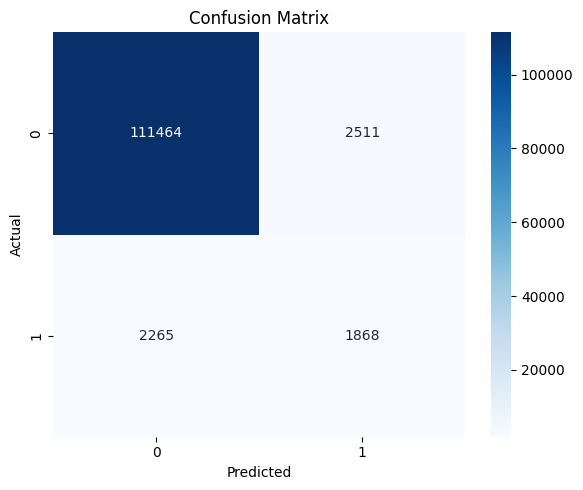

In [39]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=150)
plt.show()

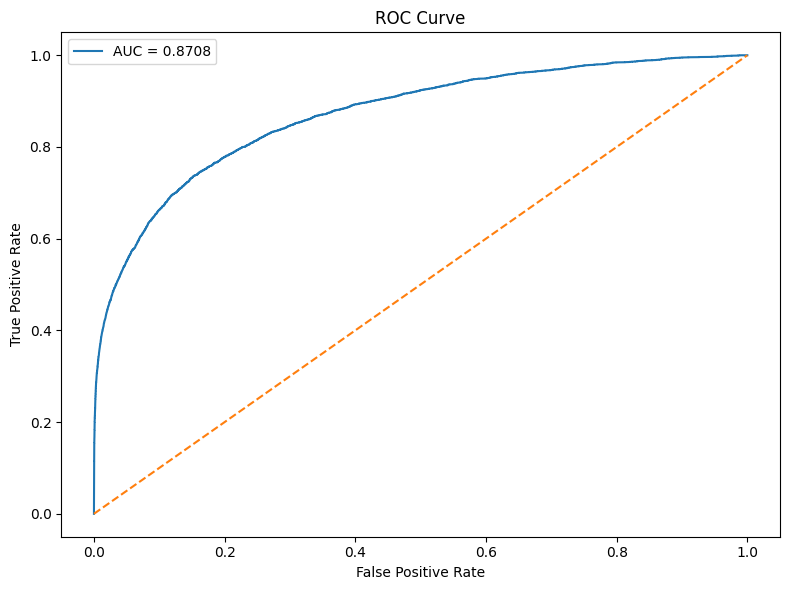

In [40]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba_best):.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_curve.png", dpi=150)
plt.show()

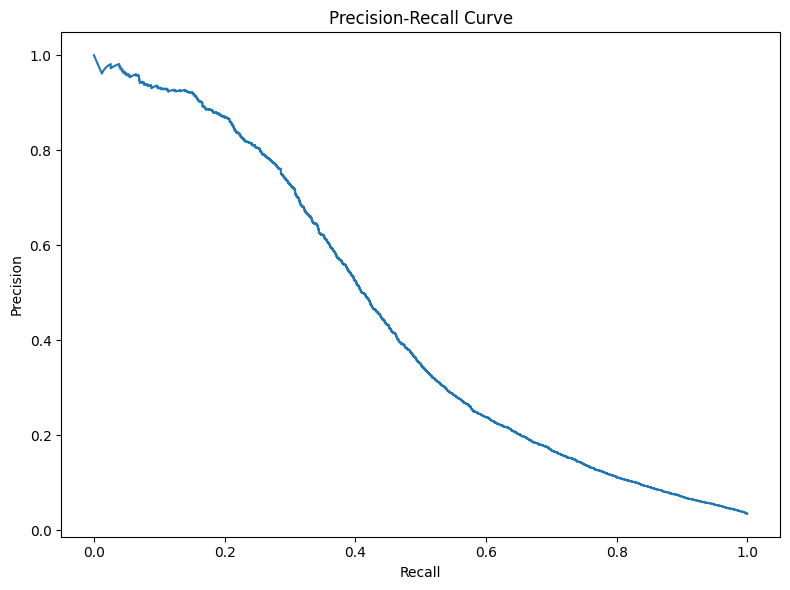

In [41]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.savefig("figures/pr_curve.png", dpi=150)
plt.show()

In [42]:
best_model.save("models/fraud_detection_model.keras")
print("Model saved: models/fraud_detection_model.keras")

Model saved: models/fraud_detection_model.keras


In [43]:
pd.DataFrame(best_results, index=["Best Model"]).T.to_csv(
    "reports/final_metrics.csv"
)

comparison.to_csv(
    "reports/model_comparison.csv"
)

print("Saved:")
print("- reports/final_metrics.csv")
print("- reports/model_comparison.csv")

Saved:
- reports/final_metrics.csv
- reports/model_comparison.csv


In [44]:
print("="*50)
print("FRAUD DETECTION PROJECT COMPLETE")
print("="*50)

print("\nBest Parameters:")
print(best_params)

print("\nBest Threshold:")
print(best_threshold)

print("\nFinal Metrics:")
print(pd.DataFrame(best_results, index=["Best Model"]).T)

print("\nOutput Files:")
print("- models/fraud_detection_model.keras")
print("- reports/final_metrics.csv")
print("- reports/model_comparison.csv")
print("- figures/confusion_matrix.png")
print("- figures/roc_curve.png")
print("- figures/pr_curve.png")

FRAUD DETECTION PROJECT COMPLETE

Best Parameters:
{'units1': 64, 'units2': 64, 'dropout': 0.13930455345098772, 'learning_rate': 0.0007454271793289181, 'batch_size': 128}

Best Threshold:
0.8000000000000003

Final Metrics:
           Best Model
Accuracy     0.959562
Precision    0.426581
Recall       0.451972
F1           0.438910
ROC_AUC      0.870757
PR_AUC       0.450075

Output Files:
- models/fraud_detection_model.keras
- reports/final_metrics.csv
- reports/model_comparison.csv
- figures/confusion_matrix.png
- figures/roc_curve.png
- figures/pr_curve.png
